# BraTS with 2D tif MRI

## Imports

In [1]:
import os

import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import random_split
import torch
import torch.optim as optim

from PIL import Image
import numpy as np
from sklearn.metrics import confusion_matrix
import random
import math
import matplotlib.pyplot as plt
import seaborn as sns

RAND_SEED = 18
brats_dir_path = "../data/raw/brats_tif"
brats_metadata_path = "../data/raw/brats_tif/data.csv"
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("NVIDIA Cuda available: ", torch.cuda.is_available())
print("GPU: ", torch.cuda.get_device_name(0))

NVIDIA Cuda available:  True
GPU:  NVIDIA GeForce GTX 1050 Ti


## Utils

In [2]:
def get_images_and_masks(data_path):
    images = []
    masks = []
    for patient_folder in os.listdir(data_path):
        patient_path = os.path.join(data_path, patient_folder)
        if not os.path.isdir(patient_path):
            continue
        patient_images = [os.path.join(patient_path, f) for f in os.listdir(patient_path) if not f.lower().endswith('mask.tif')]
        for img in patient_images:
            mask = os.path.join(patient_path, os.path.splitext(os.path.basename(img))[0] + "_mask.tif")
            if os.path.exists(mask): # Has both MRI and mask
                images.append(img)
                masks.append(mask)
    return images, masks

class BraTSDatasetTIF(Dataset):
    def __init__(self, image_paths, mask_paths, img_transform=None, mask_transform=None):
        if len(image_paths) != len(mask_paths):
            raise ValueError("#Imgs and #Masks are not equal")
        self.image_paths = image_paths
        self.mask_paths = mask_paths
        self.img_transform = img_transform
        self.mask_transform = mask_transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img = Image.open(self.image_paths[idx]).convert("RGB")
        mask = Image.open(self.mask_paths[idx]).convert("L")
        if self.img_transform:
            img = self.img_transform(img)
        if self.mask_transform:
            mask = self.mask_transform(mask)
        return img, mask

def visualize_random_batch(dataset, n=6, rand_seed=None, show_mask=True):
    if rand_seed is not None:
        random.seed(rand_seed)
        torch.manual_seed(rand_seed)

    indices = random.sample(range(len(dataset)), n)
    cols = 3
    rows = math.ceil(n / cols)
    plt.figure(figsize=(cols * 4, rows * 4))

    for i, idx in enumerate(indices):
        img, mask = dataset[idx]
        img_np = img * 0.5 + 0.5 # Undo Normalize
        img_np = img_np.permute(1, 2, 0).numpy()
        mask_np = mask.squeeze().numpy()

        plt.subplot(rows, cols, i + 1)
        plt.imshow(img_np)
        if show_mask:
            plt.imshow(mask_np, cmap='Reds', alpha=0.4)  # Overlay mask
        plt.axis("off")
        plt.title(f"Sample {idx}")

    plt.tight_layout()
    plt.show()

#### Get data & visualizations

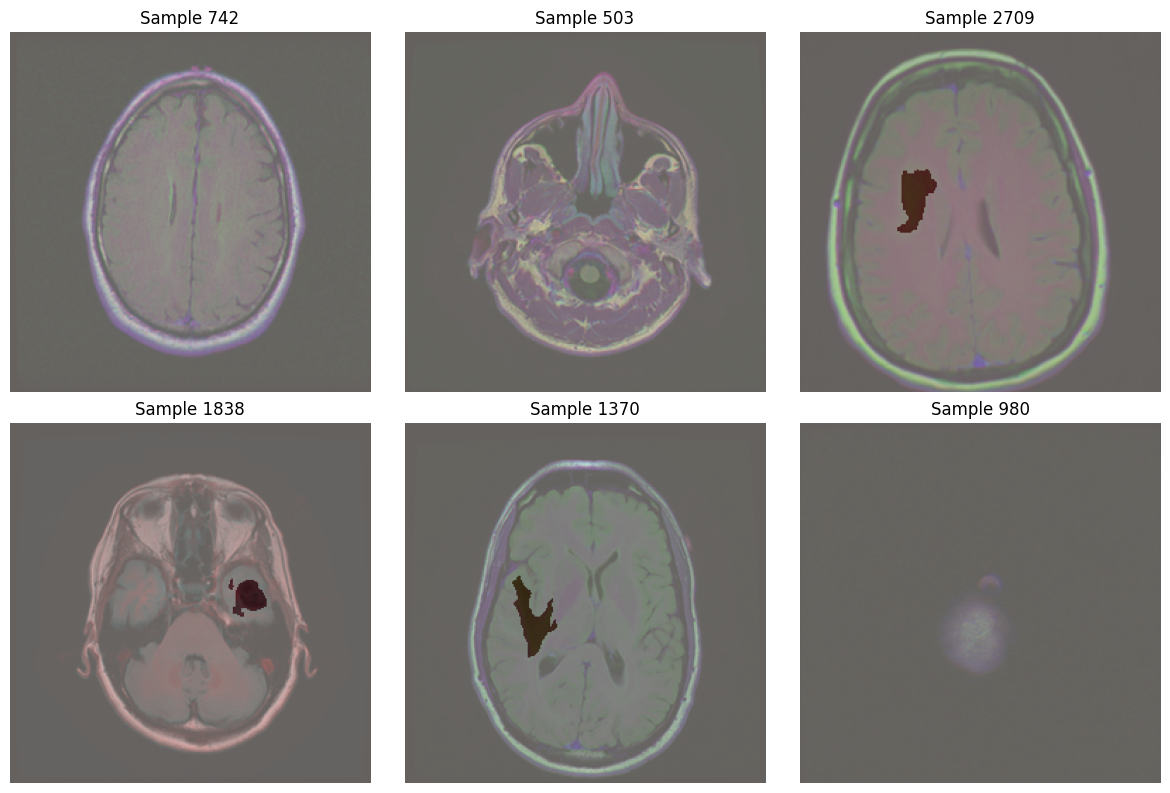

In [12]:
image_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5]*3, std=[0.5]*3)
])

mask_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.ToTensor()
])

imgs, masks = get_images_and_masks(brats_dir_path)
dataset = BraTSDatasetTIF(imgs, masks, image_transform, mask_transform)
visualize_random_batch(dataset, n=6, rand_seed=RAND_SEED, show_mask=True)

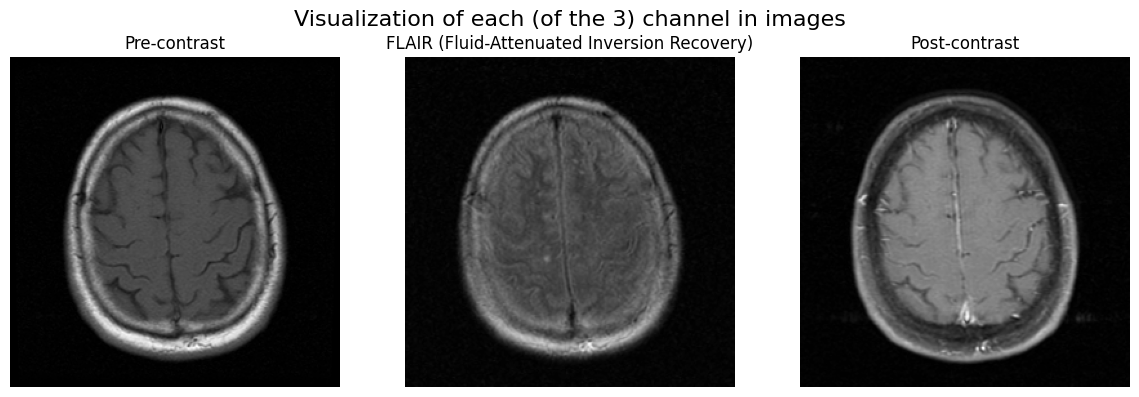

In [13]:
fig, axs = plt.subplots(1, 3, figsize=(12, 4))
sequence_names = ['Pre-contrast', 'FLAIR (Fluid-Attenuated Inversion Recovery)', 'Post-contrast']

for i in range(3):
    axs[i].imshow(dataset[10][0][i], cmap='gray')
    axs[i].set_title(sequence_names[i])
    axs[i].axis('off')

fig.suptitle("Visualization of each (of the 3) channel in images", fontsize=16)
plt.tight_layout()
plt.show()

## Model training

In [14]:
# Check mobile net V2 architecture
base = models.mobilenet_v2(weights=None).features
print(base)

Sequential(
  (0): Conv2dNormActivation(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU6(inplace=True)
  )
  (1): InvertedResidual(
    (conv): Sequential(
      (0): Conv2dNormActivation(
        (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
        (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU6(inplace=True)
      )
      (1): Conv2d(32, 16, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (2): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
  )
  (2): InvertedResidual(
    (conv): Sequential(
      (0): Conv2dNormActivation(
        (0): Conv2d(16, 96, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (1): BatchNorm2d(96, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (

### training

In [4]:
# MobileNetV2 U-Net Model
class MobileNetV2UNet(nn.Module):
    def __init__(self, num_classes=1):
        super().__init__()
        base = models.mobilenet_v2(weights=None).features
        self.enc0 = base[0:2]   # Output: 16
        self.enc1 = base[2:4]   # Output: 24
        self.enc2 = base[4:7]   # Output: 32
        self.enc3 = base[7:14]  # Output: 96
        self.enc4 = base[14:]   # Output: 1280

        self.up1 = self._upsample_block(1280, 96)
        self.up2 = self._upsample_block(96 + 96, 64)
        self.up3 = self._upsample_block(64 + 32, 32)
        self.up4 = self._upsample_block(32 + 24, 24)
        self.up5 = self._upsample_block(24 + 16, 16)

        self.final = nn.Conv2d(16, num_classes, kernel_size=1)

    def _upsample_block(self, in_ch, out_ch):
        return nn.Sequential(
            nn.ConvTranspose2d(in_ch, out_ch, kernel_size=2, stride=2),
            nn.ReLU(inplace=True),
            nn.BatchNorm2d(out_ch)
        )

    def forward(self, x):
        # Encoder side
        e0 = self.enc0(x)  # 16
        e1 = self.enc1(e0) # 24
        e2 = self.enc2(e1) # 32
        e3 = self.enc3(e2) # 96
        e4 = self.enc4(e3) # 1280

        # Decoder side and skip connections
        d1 = self.up1(e4)                    # → 96
        d2 = self.up2(torch.cat([d1, e3], dim=1))  # → 64
        d3 = self.up3(torch.cat([d2, e2], dim=1))  # → 32
        d4 = self.up4(torch.cat([d3, e1], dim=1))  # → 24
        d5 = self.up5(torch.cat([d4, e0], dim=1))  # → 16

        out = self.final(d5)                # → 1
        return torch.sigmoid(out)

# Metrics
def dice_score(pred, target, epsilon=1e-6):
    pred = (pred > 0.5).float()
    target = target.float()
    intersection = (pred * target).sum(dim=(1, 2, 3))
    union = pred.sum(dim=(1, 2, 3)) + target.sum(dim=(1, 2, 3))
    dice = (2. * intersection + epsilon) / (union + epsilon)
    return dice.mean()

In [6]:
# Inference & Visualization
def visualize_predictions(model, dataset, n=4):
    model.eval()
    indices = random.sample(range(len(dataset)), n)
    plt.figure(figsize=(12, n * 3))
    for i, idx in enumerate(indices):
        img, mask = dataset[idx]
        with torch.no_grad():
            pred = model(img.unsqueeze(0).to(device)).cpu().squeeze().numpy()
        img_np = img.permute(1, 2, 0).numpy() * 0.5 + 0.5
        mask_np = mask.squeeze().numpy()
        pred_np = (pred > 0.5).astype(float)

        plt.subplot(n, 3, i * 3 + 1)
        plt.imshow(img_np)
        plt.title("Image")
        plt.axis("off")

        plt.subplot(n, 3, i * 3 + 2)
        plt.imshow(mask_np, cmap="gray")
        plt.title("Ground Truth")
        plt.axis("off")

        plt.subplot(n, 3, i * 3 + 3)
        plt.imshow(pred_np, cmap="gray")
        plt.title("Prediction")
        plt.axis("off")

    plt.tight_layout()
    plt.show()

Epoch 1/10 - Loss: 0.6108 | Dice: 0.0925
Epoch 2/10 - Loss: 0.4948 | Dice: 0.1811
Epoch 3/10 - Loss: 0.3761 | Dice: 0.2962
Epoch 4/10 - Loss: 0.2748 | Dice: 0.4764
Epoch 5/10 - Loss: 0.1955 | Dice: 0.5722
Epoch 6/10 - Loss: 0.1385 | Dice: 0.5791
Epoch 7/10 - Loss: 0.0973 | Dice: 0.6260
Epoch 8/10 - Loss: 0.0703 | Dice: 0.6683
Epoch 9/10 - Loss: 0.0535 | Dice: 0.6472
Epoch 10/10 - Loss: 0.0398 | Dice: 0.6998


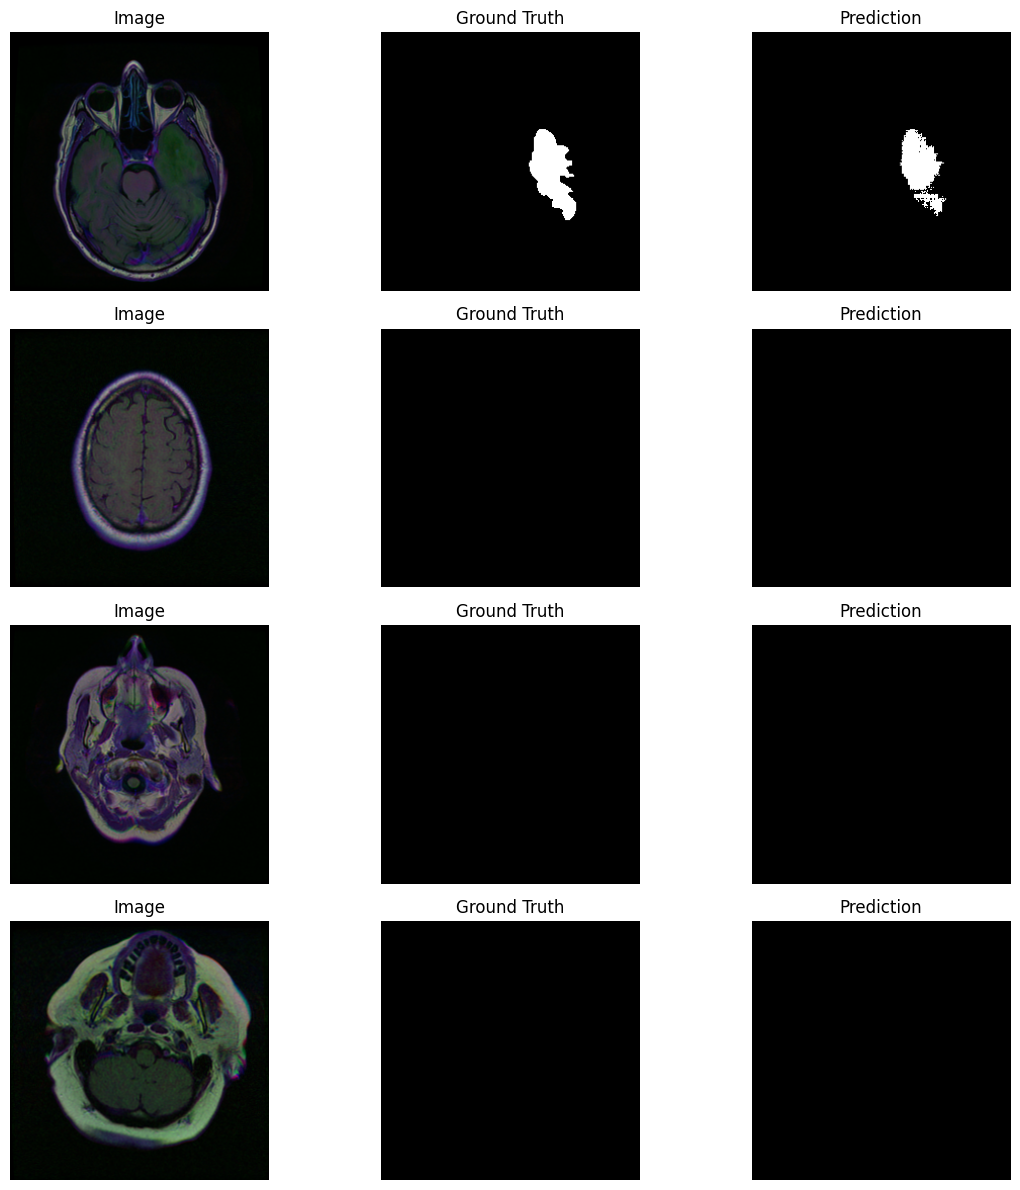

In [9]:
# Training Loop
def train_model(model, loader, criterion, optimizer, num_epochs=10):
    model.train()
    for epoch in range(num_epochs):
        epoch_loss, epoch_dice = 0, 0
        for imgs, masks in loader:
            imgs, masks = imgs.to(device), masks.to(device)
            outputs = model(imgs)
            if outputs.shape != masks.shape:
                masks = F.interpolate(masks, size=outputs.shape[2:], mode='nearest')
            loss = criterion(outputs, masks)
            dice = dice_score(outputs, masks)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            epoch_loss += loss.item()
            epoch_dice += dice.item()

        print(f"Epoch {epoch+1}/{num_epochs} - Loss: {epoch_loss/len(loader):.4f} | Dice: {epoch_dice/len(loader):.4f}")

# Hyperparams & Run
brats_dir_path = "../data/raw/brats_tif"
image_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3)
])
mask_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.ToTensor()
])

imgs, masks = get_images_and_masks(brats_dir_path)
dataset = BraTSDatasetTIF(imgs, masks, image_transform, mask_transform)
dataloader = DataLoader(dataset, batch_size=8, shuffle=True)

model = MobileNetV2UNet().to(device)
criterion = nn.BCELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

train_model(model, dataloader, criterion, optimizer, num_epochs=10)

# Save model
torch.save(model.state_dict(), "../models/brats_tif_mobilenetv2_unet.pth")

# model = MobileNetV2UNet().to(device)
# model.load_state_dict(torch.load("../models/brats_tif_mobilenetv2_unet.pth", weights_only=True))

visualize_predictions(model, dataset)

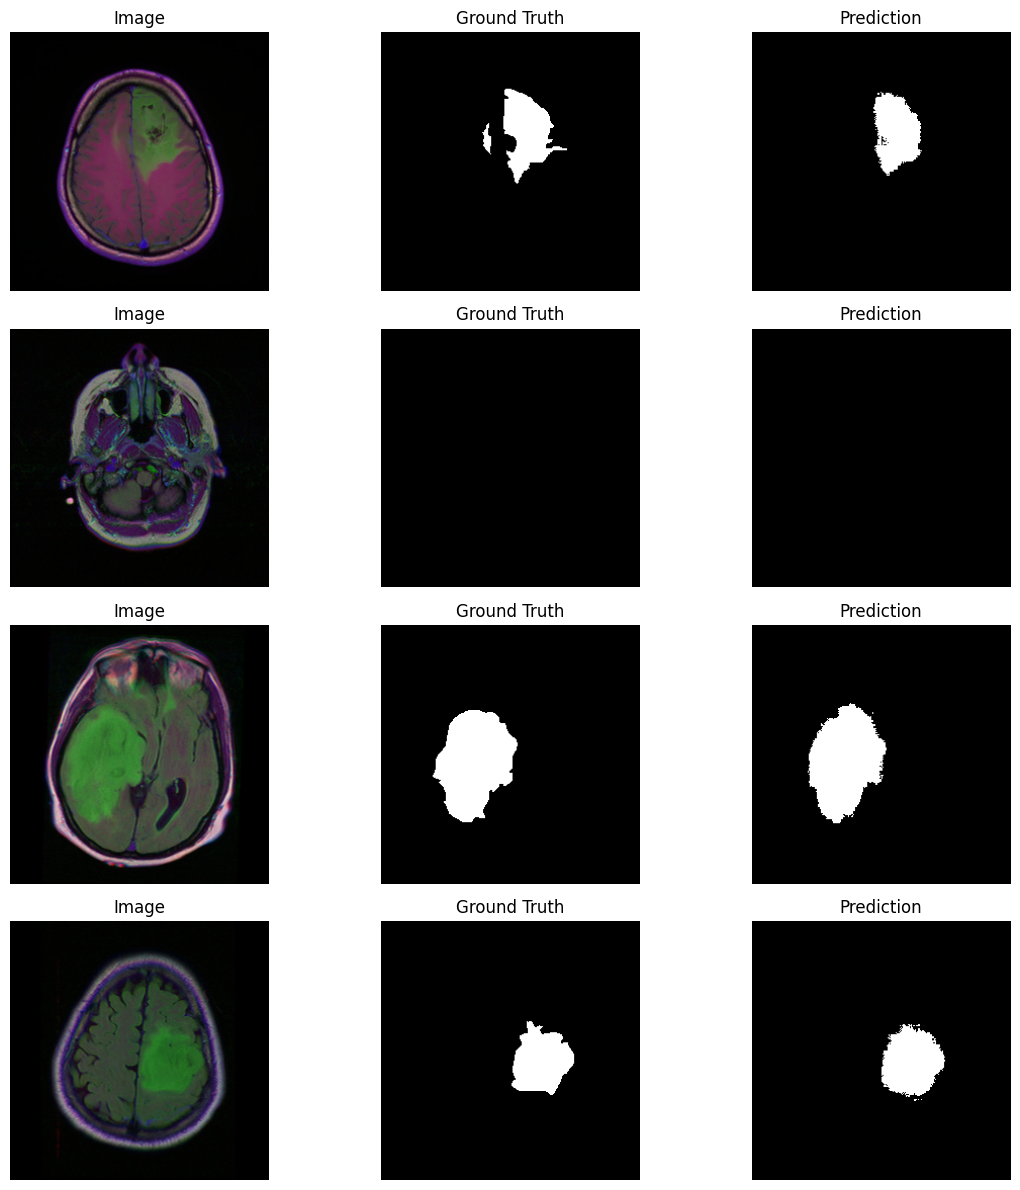

In [9]:
# Hyperparams & Run
brats_dir_path = "../data/raw/brats_tif"
image_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3)
])
mask_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.ToTensor()
])

imgs, masks = get_images_and_masks(brats_dir_path)
dataset = BraTSDatasetTIF(imgs, masks, image_transform, mask_transform)
dataloader = DataLoader(dataset, batch_size=8, shuffle=True)

model = MobileNetV2UNet().to(device)
model.load_state_dict(torch.load("../models/brats_tif_mobilenetv2_unet.pth", weights_only=True))
criterion = nn.BCELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

visualize_predictions(model, dataset)